I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


# EX5.1

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

In [3]:
car_mileages = pd.read_csv("passengercarmileage.txt", sep='\t')

car_mileages

,makeAndModel,VOL,HP,MPG,SP,WT
0,GM/GeoMetroXF1,89,49,65.4,96,17.5
1,GM/GeoMetro,92,55,56.0,97,20.0
2,GM/GeoMetroLSI,92,55,55.9,97,20.0
3,SuzukiSwift,92,70,49.0,105,20.0
4,DaihatsuCharade,92,53,46.5,96,20.0
...,...,...,...,...,...,...
77,Mercedes500SL,50,322,18.1,165,45.0
78,Mercedes560SEL,115,238,17.2,140,45.0
79,JaguarXJSConvert,50,263,17.0,147,45.0
80,BMW750IL,119,295,16.7,157,45.0


In [4]:
X = car_mileages["HP"].values
Y = car_mileages["MPG"].values

with pm.Model() as model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * X
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y)
    
    trace = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace, var_names=["alpha", "beta", "sigma"]))

NUTS[nutpie]: [alpha, beta, sigma]


Output()

          mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha     50.1    1.58       48       53     1056     1272  1.00     0.049    0.033
beta   -0.1393  0.0121    -0.16    -0.12     1081     1355  1.00   0.00037  0.00025
sigma     6.26    0.49      5.5      7.1     2038     2023  1.00     0.011   0.0081


Sampling: [y_obs]


Output()

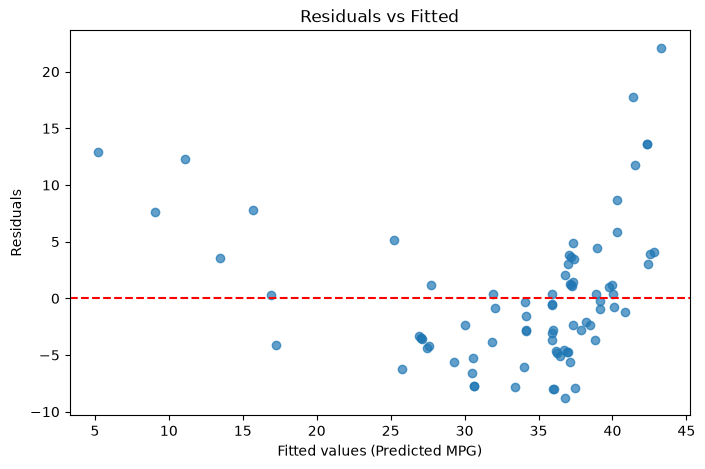

In [5]:
#non-log
with model:
    ppc = pm.sample_posterior_predictive(trace)

#mean predicted values
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
residuals = Y - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#the shape is curved (kind of U-shaped), there isn't a clear linear relationship here.

In [6]:
Y_log = np.log(car_mileages["MPG"].values)

with pm.Model() as log_model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * X
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_log)
    
    trace_log = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace_log, var_names=["alpha", "beta", "sigma"]))

NUTS[nutpie]: [alpha, beta, sigma]


Output()

           mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha     4.012    0.041      3.9      4.1     1169     1413  1.00    0.0012  0.00086
beta   -0.00458  0.00032  -0.0051  -0.0041     1159     1503  1.00   9.3e-06  7.1e-06
sigma    0.1604   0.0134     0.14     0.18     2169     1848  1.00   0.00029  0.00025


Sampling: [y_obs]


Output()

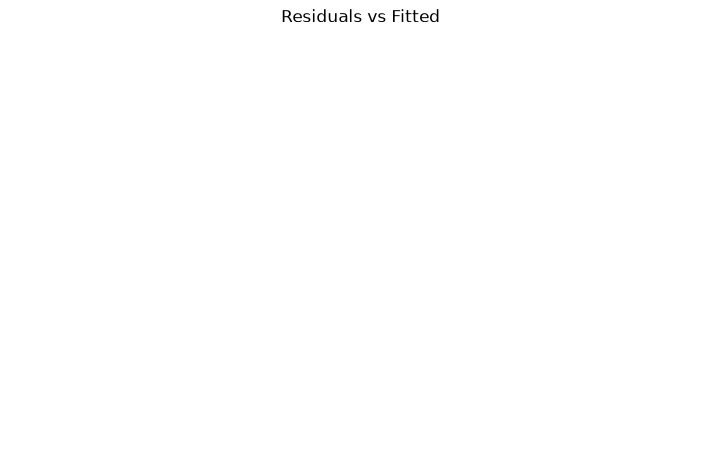

In [7]:
#logged
with model:
    ppc = pm.sample_posterior_predictive(trace_log)

#mean predicted values
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
residuals = Y_log - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#the shape is better, so improved linear relationship, but not perfect

In [17]:
X_multi = car_mileages[["VOL", "HP", "SP", "WT"]].values
Y_multi = car_mileages["MPG"].values

#normalize
X_mean = X_multi.mean(axis=0)
X_std = X_multi.std(axis=0)
X_scaled = (X_multi - X_mean) / X_std


with pm.Model() as multi_model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    #coefficient vector
    betas = pm.Normal("betas", mu=0, sigma=10, shape=4)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + pm.math.dot(X_scaled, betas)
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_multi)
    
    trace_multi = pm.sample(draws=1000, tune=1000, return_inferencedata=True)
    trace_multi = pm.sample_posterior_predictive(
            trace_multi, 
            extend_inferencedata=True
        )
# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace_multi, var_names=["alpha", "betas", "sigma"]))

NUTS[nutpie]: [alpha, betas, sigma]


Output()

Sampling: [y_obs]


Output()

           mean    sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
alpha     33.78  0.41       33       34     3569     2474  1.00    0.0068  0.0071
betas[0]  -0.52  0.51     -1.3      0.3     3108     2745  1.00    0.0092  0.0087
betas[1]   15.7   3.9      9.3       22      482      762  1.00      0.18    0.12
betas[2]  -13.3   2.9      -18     -8.6      501      821  1.00      0.13   0.083
betas[3]  -12.8  1.52      -15      -10      556      899  1.00     0.065   0.039
sigma      3.74  0.31      3.3      4.3     3107     2614  1.00    0.0055  0.0053


In [18]:
# import arviz_stats as az
# r2_summary = az.bayesian_r2(Y_multi, trace_multi)
# print(r2_summary)

# y_pred_multi = trace_multi.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
y_pred_multi = trace_multi.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
ss_res = np.sum((Y_multi - y_pred_multi) ** 2)
ss_tot = np.sum((Y_multi - np.mean(Y_multi)) ** 2)
r2_multi = 1 - (ss_res / ss_tot)

print("Multiple Model R²:", r2_multi)


Multiple Model R²: 0.8687574672023537


### Personal notes
-  outcome $y$ as a Normal distribution centered on our line:$$\text{MPG}_i \sim \text{Normal}(\mu_i, \sigma)$$$$\mu_i = \alpha + \beta \cdot \text{HP}_i$$
-  Posterior Predictive Checks (PPC) to compute the predicted values ($\hat{y}$) and calculate the residuals
-  Heteroscedasticity means that the variance of errors or residuals in a statistical model is not constant across the values of an independent variable

# Ex5.2

1. Least Squares Estimate

residuals:
$$e_i = Y_i - \beta X_i$$

$$RSS = \sum_{i=1}^n (Y_i - \beta X_i)^2$$


Chain rule:

$u = Y_i - \beta X_i$

$\frac{d}{du} = 2u$
$\frac{d}{d\beta} = -X_i$

$\frac{d}{du} * \frac{d}{\beta} = -2X_iu
=-2X_i(Y_i - \beta X_i)$


$$\frac{dRSS}{d\beta} = \sum_{i=1}^n -2 X_i (Y_i - \beta X_i)$$

$$ -2\sum_{i=1}^n (X_iY_i - \beta X_i^2)$$

$$\sum_{i=1}^n X_i Y_i - \sum_{i=1}^n \beta X_i^2 = 0$$

$$\sum_{i=1}^n X_i Y_i - \beta \sum_{i=1}^n X_i^2$$

Estimator: $\hat\beta$
$$\hat\beta = \frac{-\sum_{i=1}^n X_i Y_i}{-\sum_{i=1}^n X_i^2}$$
$$ = \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2}$$

2. Bias of an estimator

$$\text{Bias}(\hat{\beta}) = \mathbb{E}(\hat{\beta}) - \beta$$



$Y_i = \beta X_i + \epsilon_i$

$$\hat{\beta} = \frac{\sum_{i=1}^n X_i (\beta X_i + \epsilon_i)}{\sum_{i=1}^n X_i^2}$$

$$= \frac{\sum_{i=1}^n \beta X_i^2 + \epsilon_i X_i}{\sum_{i=1}^n X_i^2}$$

$$= \frac{\beta\sum_{i=1}^n X_i^2}{\sum_{i=1}^n X_i^2} + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}$$

$$= \beta + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}$$


Given: $\mathbb{E}(X_i \epsilon_i) = 0$ for all $i$
$$\mathbb{E}(\hat{\beta}) = \mathbb{E}\left(\beta + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}\right)$$

$$= \beta + \mathbb{E}\left(\frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}\right)$$

$$= \beta + 0 = \beta$$


$$\text{Bias}(\hat{\beta}) = \mathbb{E}(\hat{\beta}) - \beta = \beta - \beta = 0$$



### personal notes
- $Y_i = \beta X_i + \epsilon_i$ -- forced to pass through the origin since $\beta_0$ isn't present
- In regular regression with an intercept, the slope is $\frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}$
- Expectation is linear

# Ex5.3

NUTS[nutpie]: [theta]


Output()

        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta  0.132  0.193    -0.18     0.44     3519     4811  1.00    0.0032  0.0021


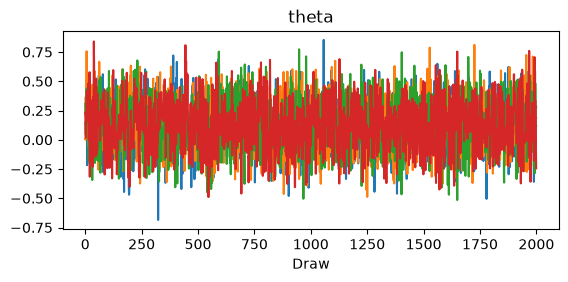

In [12]:
import pymc as pm
import numpy as np
import arviz as az  # Used for posterior analysis and diagnostics

# 1. Load Data
X_data = np.array([
    -0.02, -0.03, 0.82, -1.05, -0.76, 0.46, -0.06, 0.34, -0.08, -0.24, 
     1.43,  1.07, -2.5 ,  1.48,  2.16, 1.23, -0.21, -0.69, 0.73, -0.62
])

sigma_known = 1.0
theta_mean = 0.0
theta_std = 0.4  # Notice std = sqrt(0.4^2) = 0.4

# 2. Build Model
with pm.Model() as model_part_a:
    # Prior for theta: N(0, 0.4^2)
    theta = pm.Normal('theta', mu=theta_mean, sigma=theta_std)
    
    # Likelihood: X ~ N(theta, 1^2)
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma_known, observed=X_data)
    
    # 3. Sample from Posterior
    idata_a = pm.sample(draws=2000, tune=1000, random_seed=42)

# 4. Check Results and Diagnostics
az.plot_trace(idata_a)
summary_a = az.summary(idata_a, var_names=['theta'])
print(summary_a)

NUTS[nutpie]: [theta, sigma]


Output()

        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta  0.127  0.209     -0.2     0.46     6988     5583  1.00    0.0025  0.0026
sigma  1.089  0.177     0.85      1.4     7377     5698  1.00    0.0021  0.0026


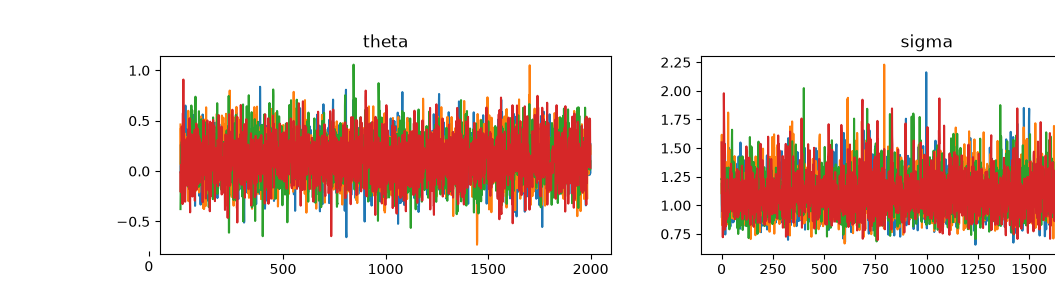

In [8]:
with pm.Model() as model_part_b:
    # Prior for theta: N(0, 0.4^2)
    theta = pm.Normal('theta', mu=0.0, sigma=0.4)
    
    # Prior for sigma: Gamma(alpha=2, beta=2)
    sigma = pm.Gamma('sigma', alpha=2.0, beta=2.0)
    
    # Likelihood using the random parameter sigma
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma, observed=X_data)
    
    # Sample from the joint posterior
    idata_b = pm.sample(draws=2000, tune=1000, random_seed=42)

# Diagnostics and summary for both parameters
az.plot_trace(idata_b)
summary_b = az.summary(idata_b, var_names=['theta', 'sigma'])
print(summary_b)

### personal notes
- The thetas are about the same in both cases. With the unknown $\sigma$ case's std being ever so slightly higher than in the known case.
- eti89_lb / eti89_ub: equal-tailed interval. tells the 89% confidence of what range the true value lies in (in this case $\theta$)
- ess_bulk / ess_tail: Effective sample size. estimate of independent draws.
- r_hat: Gelmans-rubin diagnostic ($\hat R$). Convergence measure across chains, value less than 1.05 signifies good mixing.
- mcse_mean / mcse_sd: Monnte Carlo Standard Error. Estimation error of MCMC sampling.
- A good plot looks like a caterpillar. Overlapping colors, noise stays stationary.

In [13]:
# Proportion of sampled theta values that are greater than 0
prob_greater_than_zero = (idata_a.posterior['theta'] > 0).mean().values
print(prob_greater_than_zero)

0.760375


# Ex5.4



NUTS[nutpie]: [beta0, beta1, sigma]


Output()

        mean    sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
beta0   0.25  0.85     -1.1      1.6     3187     4080  1.00     0.015  0.0097
beta1  0.788  0.17     0.52      1.1     2907     3909  1.00    0.0032  0.0022
sigma   2.34  0.51      1.7      3.2     4148     4493  1.00    0.0083    0.01


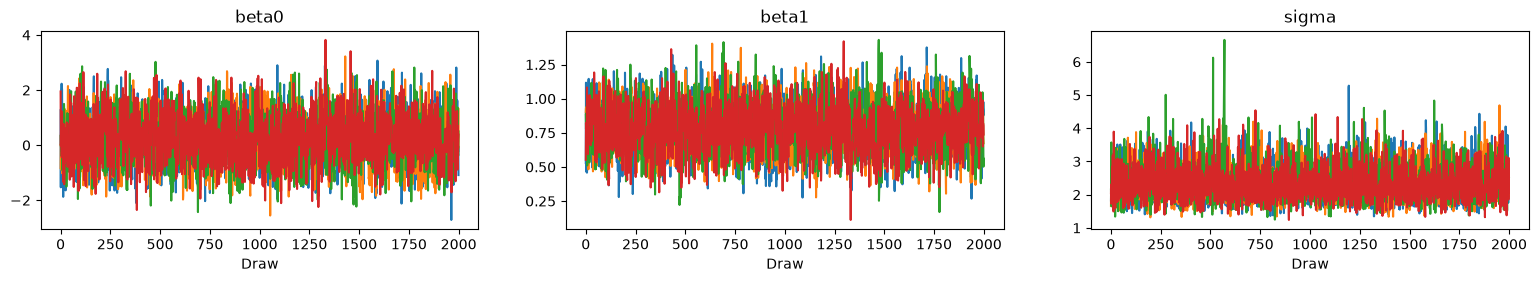

In [16]:
# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=2000, return_inferencedata=True)

az.plot_trace(idata)
summary = az.summary(idata, var_names=['beta0', 'beta1', 'sigma'])
print(summary)
#the convergence succeeded despite the outlier, though the slope and intercept suffered slightly

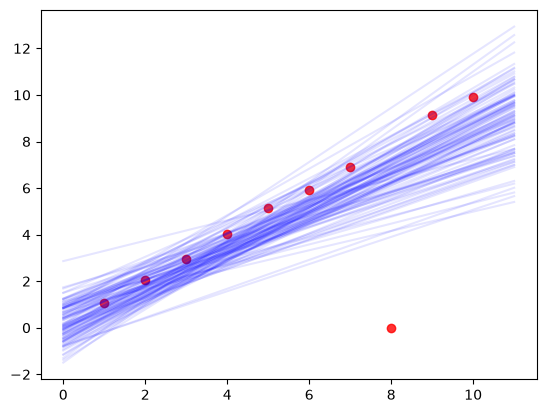

In [17]:
posterior_beta0 = idata.posterior['beta0'].values.flatten()
posterior_beta1 = idata.posterior['beta1'].values.flatten()

indices = np.random.choice(len(posterior_beta0), size=100, replace=False)

# Plot each line
x_vals = np.linspace(0, 11, 100)
for idx in indices:
    b0 = posterior_beta0[idx]
    b1 = posterior_beta1[idx]
    plt.plot(x_vals, b0 + b1 * x_vals, color='blue', alpha=0.1)

plt.scatter(X_data, Y_data, color='red', alpha=0.8)
#there's a lot of variation for the lines, many are clearly bad fits
#only some lines are decent
#showing that if we randomly pick lines a lot of them likely to be bad

NUTS[nutpie]: [beta0, beta1, sigma]


Output()

         mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
beta0   0.063  0.106   -0.094     0.22     1720     2059  1.00    0.0027   0.005
beta1  0.9885  0.019     0.96        1     1749     2209  1.00   0.00047  0.0007
sigma   0.138  0.073    0.064     0.26     2007     2514  1.00    0.0016  0.0032


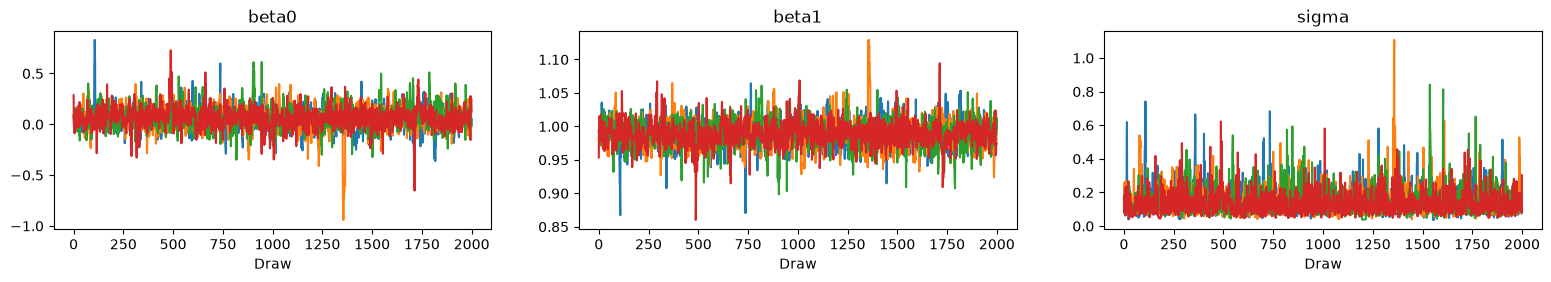

In [5]:
# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0
nu = 3

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.StudentT('Y_obs', nu=nu, mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=2000, return_inferencedata=True)

az.plot_trace(idata)
summary = az.summary(idata, var_names=['beta0', 'beta1', 'sigma'])
print(summary)

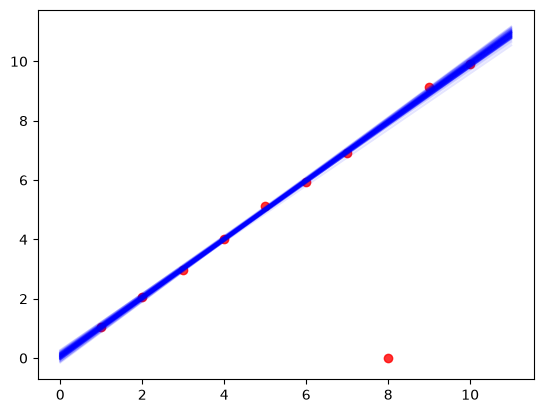

In [15]:
posterior_beta0 = idata.posterior['beta0'].values.flatten()
posterior_beta1 = idata.posterior['beta1'].values.flatten()

indices = np.random.choice(len(posterior_beta0), size=100, replace=False)

# Plot each line
x_vals = np.linspace(0, 11, 100)
for idx in indices:
    b0 = posterior_beta0[idx]
    b1 = posterior_beta1[idx]
    plt.plot(x_vals, b0 + b1 * x_vals, color='blue', alpha=0.1)

plt.scatter(X_data, Y_data, color='red', alpha=0.8)
#with the restricted degrees of freedom,
#the lines are a much better fit than before
#no longer shooting in random directions, mostly uniform

### Personal notes
- standard linear regression shifts or tilts regression line toward extreme outliers if they exist, messing with the main cluster.
- studen-t assign higher probabilities to points further from the mean. better avoids shifting and tilting from main cluster